In [16]:
pip show yfinance


Name: yfinance
Version: 0.2.59
Summary: Download market data from Yahoo! Finance API
Home-page: https://github.com/ranaroussi/yfinance
Author: Ran Aroussi
Author-email: ran@aroussi.com
License: Apache
Location: C:\Users\ionak\anaconda3\Lib\site-packages
Requires: beautifulsoup4, curl_cffi, frozendict, multitasking, numpy, pandas, peewee, platformdirs, protobuf, pytz, requests, websockets
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [17]:
import yfinance as yf
import pandas as pd

#Δίνω τα tickers από τις 3 μετοχές (Procter & Gamble, Pepsi, Colgate-Palmolive)
tickers = ['PG', 'PEP', 'CL']  

all_data = pd.DataFrame()

#Κατεβάζουμε δεδομένα από 5 χρόνια για κάθε μετοχή
#Εμφανίζω τις τιμές κλεισίματος σε έναν πίνακα
for t in tickers:
    print(f"\nΚατεβάζω δεδομένα για: {t}")
    try:
        ticker = yf.Ticker(t)
        df = ticker.history(start="2020-01-01", end="2025-01-01", interval="1d")['Close'] #Close is the same as Adj Close
        df.name = t  # Set the series name to the ticker symbol
        all_data = pd.concat([all_data, df], axis=1)
        print(f"Ολοκληρώθηκε για {t}")
    except Exception as e:
        print(f"Σφάλμα για {t}: {e}")

print("\nΣυγκεντρωτικά δεδομένα:")
print(all_data.tail())



Κατεβάζω δεδομένα για: PG
Ολοκληρώθηκε για PG

Κατεβάζω δεδομένα για: PEP
Ολοκληρώθηκε για PEP

Κατεβάζω δεδομένα για: CL
Ολοκληρώθηκε για CL

Συγκεντρωτικά δεδομένα:
                                   PG         PEP         CL
2024-12-24 00:00:00-05:00  166.875900  149.826797  91.358162
2024-12-26 00:00:00-05:00  168.080994  149.464020  91.338387
2024-12-27 00:00:00-05:00  167.458694  149.905228  90.784637
2024-12-30 00:00:00-05:00  165.048492  148.758072  89.776031
2024-12-31 00:00:00-05:00  165.601654  149.091446  89.894691


In [18]:
# Υπολογίζω τις αποδόσεις για κάθε μετοχή
returns = all_data.pct_change().dropna()

# Εμφανίζω τις τελευταίες 5 αποδόσεις
returns.tail()


,PG,PEP,CL
2024-12-24 00:00:00-05:00,0.004937,0.010047,0.005223
2024-12-26 00:00:00-05:00,0.007221,-0.002421,-0.000216
2024-12-27 00:00:00-05:00,-0.003702,0.002952,-0.006063
2024-12-30 00:00:00-05:00,-0.014393,-0.007653,-0.011110
2024-12-31 00:00:00-05:00,0.003352,0.002241,0.001322


In [19]:
# Ορίζω τα βάρη κάθε μετοχής 
weights = [0.4, 0.3, 0.3]

# Υπολογίζω τις ημερήσιες αποδόσεις του χαρτοφυλακίου
portfolio_returns = returns.dot(weights)

# Εμφανίζουμε τις αποδόσεις
portfolio_returns.tail()



2024-12-24 00:00:00-05:00    0.006556
2024-12-26 00:00:00-05:00    0.002097
2024-12-27 00:00:00-05:00   -0.002414
2024-12-30 00:00:00-05:00   -0.011386
2024-12-31 00:00:00-05:00    0.002409
dtype: float64

In [20]:
# VaR με ιστορική προσομοίωση για επίπεδο εμπιστοσύνης 95% και 99%
var_95_hs = portfolio_returns.quantile(0.05)
var_99_hs = portfolio_returns.quantile(0.01)

print(f"VaR 95% (ιστορική): {var_95_hs:.4f}")
print(f"VaR 99% (ιστορική): {var_99_hs:.4f}")


VaR 95% (ιστορική): -0.0168
VaR 99% (ιστορική): -0.0300


In [21]:
import numpy as np

mean = portfolio_returns.mean()
std_dev = portfolio_returns.std()

# Z-values για 95% και 99%
z_95 = 1.65
z_99 = 2.33

var_95_vc = mean - z_95 * std_dev
var_99_vc = mean - z_99 * std_dev

print(f"VaR 95% (variance-covariance): {var_95_vc:.4f}")
print(f"VaR 99% (variance-covariance): {var_99_vc:.4f}")


VaR 95% (variance-covariance): -0.0197
VaR 99% (variance-covariance): -0.0279


In [22]:
# Rolling VaR – Ιστορική προσωμοίωση
rolling_window_size = 126  # 6 μήνες

rolling_var_95_hs = portfolio_returns.rolling(window=rolling_window_size).quantile(0.05)
rolling_var_99_hs = portfolio_returns.rolling(window=rolling_window_size).quantile(0.01)


In [23]:
portfolio_returns


2020-01-03 00:00:00-05:00   -0.003550
2020-01-06 00:00:00-05:00    0.003778
2020-01-07 00:00:00-05:00   -0.011309
2020-01-08 00:00:00-05:00    0.010889
2020-01-09 00:00:00-05:00    0.007131
                               ...   
2024-12-24 00:00:00-05:00    0.006556
2024-12-26 00:00:00-05:00    0.002097
2024-12-27 00:00:00-05:00   -0.002414
2024-12-30 00:00:00-05:00   -0.011386
2024-12-31 00:00:00-05:00    0.002409
Length: 1257, dtype: float64

In [24]:
import numpy as np

# Rolling μέση απόδοση και τυπική απόκλιση
rolling_mean = portfolio_returns.rolling(window=rolling_window_size).mean()
rolling_std = portfolio_returns.rolling(window=rolling_window_size).std()

# Υπολογισμός VaR με κανονική κατανομή
z_95 = 1.65
z_99 = 2.33

rolling_var_95_vc = rolling_mean - z_95 * rolling_std
rolling_var_99_vc = rolling_mean - z_99 * rolling_std


In [25]:
lambda_ = 0.94  # Προτεινόμενη τιμή από JP Morgan
ewma_var = []   # Λίστα για να αποθηκεύσουμε τις τυπικές αποκλίσεις

# Ξεκινάμε από την πρώτη τιμή της rolling_std
prev_var = portfolio_returns[:126].var()  # Αρχική εκτίμηση

for r in portfolio_returns[126:]:
    prev_var = lambda_ * prev_var + (1 - lambda_) * r**2
    ewma_var.append(prev_var)

# Μετατρέπουμε σε pandas Series
import numpy as np
ewma_std = pd.Series(np.sqrt(ewma_var), index=portfolio_returns[126:].index)


In [26]:
z_95 = 1.65
z_99 = 2.33

ewma_var_95 = -z_95 * ewma_std
ewma_var_99 = -z_99 * ewma_std


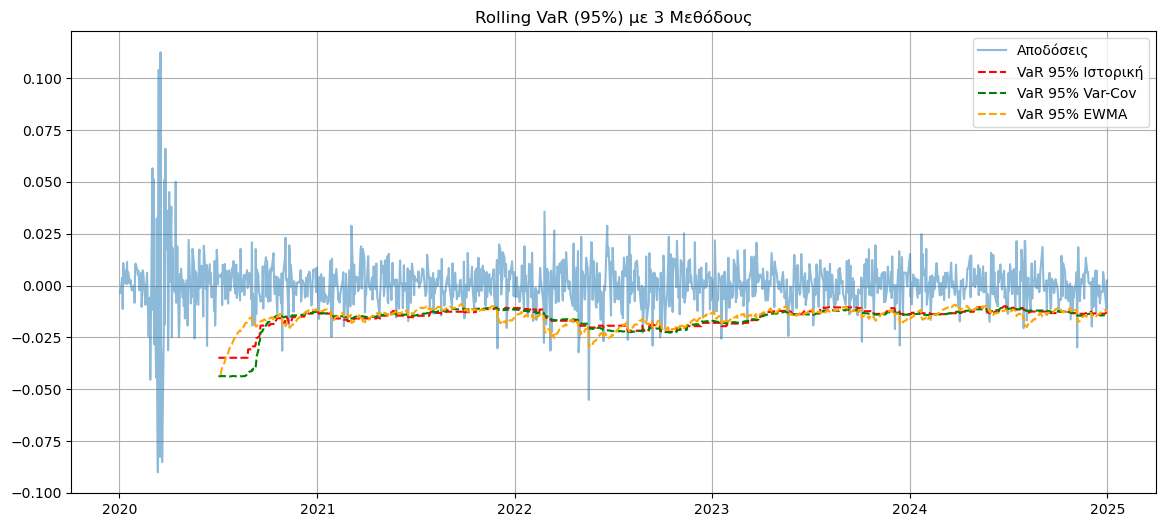

In [27]:
# Import matplotlib.pyplot library
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(portfolio_returns, label='Αποδόσεις', alpha=0.5)

# Προηγούμενα VaR(ιστορική προσομοίωση- διακύμανση συνδιακύμανση)
plt.plot(rolling_var_95_hs, label='VaR 95% Ιστορική', linestyle='--', color='red')
plt.plot(rolling_var_95_vc, label='VaR 95% Var-Cov', linestyle='--', color='green')

#VaR με μέθοδο EWMA (Exponentially Weighted Moving Average)
plt.plot(ewma_var_95, label='VaR 95% EWMA', linestyle='--', color='orange')

plt.title('Rolling VaR (95%) με 3 Μεθόδους')
plt.legend()
plt.grid(True)

In [28]:
# Κάνουμε align τις αποδόσεις με το index κάθε VaR σειράς
returns_hist = portfolio_returns.reindex(rolling_var_95_hs.index)
returns_vc   = portfolio_returns.reindex(rolling_var_95_vc.index)
returns_ewma = portfolio_returns.reindex(ewma_var_95.index)

# Υπολογισμός εξαιρέσεων
exceptions_hist = returns_hist < rolling_var_95_hs
exceptions_vc   = returns_vc   < rolling_var_95_vc
exceptions_ewma = returns_ewma < ewma_var_95

# Αποτελέσματα
print("Εξαιρέσεις (95% επίπεδο εμπιστοσύνης):\n")
print(f"Ιστορική: {exceptions_hist.sum()} σε {len(exceptions_hist)} ημέρες")
print(f"Var-Cov: {exceptions_vc.sum()} σε {len(exceptions_vc)} ημέρες")
print(f"EWMA: {exceptions_ewma.sum()} σε {len(exceptions_ewma)} ημέρες")


Εξαιρέσεις (95% επίπεδο εμπιστοσύνης):

Ιστορική: 57 σε 1257 ημέρες
Var-Cov: 54 σε 1257 ημέρες
EWMA: 52 σε 1131 ημέρες


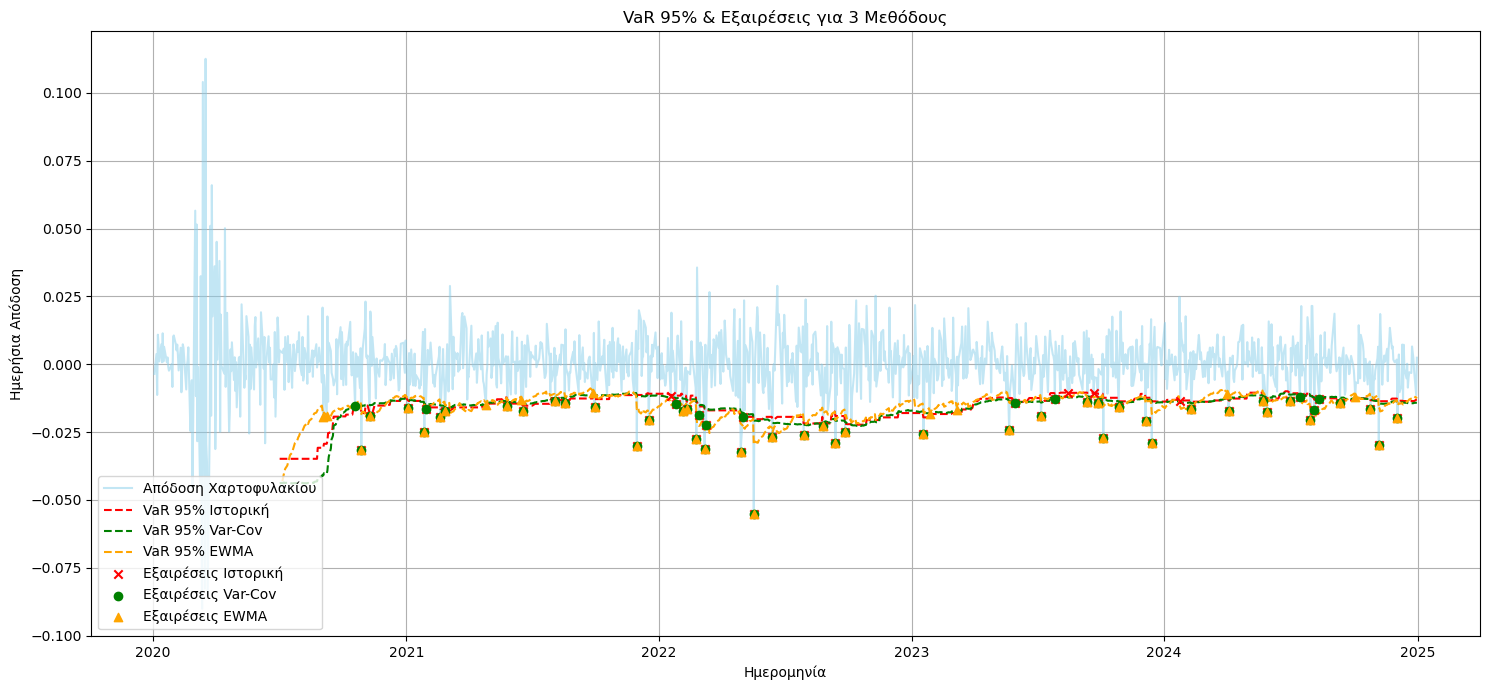

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

# Αποδόσεις χαρτοφυλακίου
plt.plot(portfolio_returns, label='Απόδοση Χαρτοφυλακίου', color='skyblue', alpha=0.5)

# Γραμμές VaR 95% για κάθε μέθοδο
plt.plot(rolling_var_95_hs, label='VaR 95% Ιστορική', linestyle='--', color='red')
plt.plot(rolling_var_95_vc, label='VaR 95% Var-Cov', linestyle='--', color='green')
plt.plot(ewma_var_95, label='VaR 95% EWMA', linestyle='--', color='orange')

# Εξαιρέσεις Ιστορική
plt.scatter(returns_hist[exceptions_hist].index,
            returns_hist[exceptions_hist],
            color='red', marker='x', label='Εξαιρέσεις Ιστορική', zorder=5)

# Εξαιρέσεις Var-Cov
plt.scatter(returns_vc[exceptions_vc].index,
            returns_vc[exceptions_vc],
            color='green', marker='o', label='Εξαιρέσεις Var-Cov', zorder=5)

# Εξαιρέσεις EWMA
plt.scatter(returns_ewma[exceptions_ewma].index,
            returns_ewma[exceptions_ewma],
            color='orange', marker='^', label='Εξαιρέσεις EWMA', zorder=5)

plt.title('VaR 95% & Εξαιρέσεις για 3 Μεθόδους')
plt.xlabel('Ημερομηνία')
plt.ylabel('Ημερήσια Απόδοση')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
from scipy.stats import chi2
import numpy as np

def kupiec_test(x, n, p=0.05):
    LR_uc = -2 * (np.log(((1 - p)**(n - x) * p**x)) -
                  np.log(((1 - x/n)**(n - x) * (x/n)**x)))
    p_value = 1 - chi2.cdf(LR_uc, df=1)
    return LR_uc, p_value

print("KUPIEC TEST – 95% VaR\n")

# Ιστορική
x_hist = exceptions_hist.sum()
n_hist = len(exceptions_hist)
LR_hist, p_hist = kupiec_test(x_hist, n_hist)

# Var-Cov
x_vc = exceptions_vc.sum()
n_vc = len(exceptions_vc)
LR_vc, p_vc = kupiec_test(x_vc, n_vc)

# EWMA
x_ewma = exceptions_ewma.sum()
n_ewma = len(exceptions_ewma)
LR_ewma, p_ewma = kupiec_test(x_ewma, n_ewma)

# Εμφάνιση
print(f"Ιστορική:\tLR = {LR_hist:.4f}, p-value = {p_hist:.4f} ➤ {'Αποδοχή' if p_hist > 0.05 else 'Απόρριψη'}")
print(f"Var-Cov:\tLR = {LR_vc:.4f}, p-value = {p_vc:.4f} ➤ {'Αποδοχή' if p_vc > 0.05 else 'Απόρριψη'}")
print(f"EWMA:\t\tLR = {LR_ewma:.4f}, p-value = {p_ewma:.4f} ➤ {'Αποδοχή' if p_ewma > 0.05 else 'Απόρριψη'}")


KUPIEC TEST – 95% VaR

Ιστορική:	LR = 0.5908, p-value = 0.4421 ➤ Αποδοχή
Var-Cov:	LR = 1.3746, p-value = 0.2410 ➤ Αποδοχή
EWMA:		LR = 0.3956, p-value = 0.5294 ➤ Αποδοχή
